# aim of this practical

We are now taking a closer look at how individual cells transition to galactose growth. 

To this end, we conducted two experiments:

1. cells were pregrown on raffinose (2%) and transferred to galactose (0.2%)
2. cells were pregrown on glucose (2%) and transferred to galactose (0.2%)

We looked at one strain, YET911 which carries
<br>
- GAl1 protein fused to mScarlet

See the figure below for a depiction of the strain features (**A**) and global experimental procedures (**B**).

![title](imgs/SC_practical_live_cell_imaging_schematic.png)

# imports

In [41]:
from skimage import io
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# inspecting the dataset

let's start by opening the dataframes:

In [2]:
data = {}

for condition in ['raff_to_gal', 'gluc_to_gal']:
    data[condition] = pd.read_csv(f'live_imaging_data/{condition}.csv')

# a crude video

let's use simple methods to visualise how the cells move and induce fluorescence over time


the function below puts a dot whose size is proportional to the area of a cell, 
and whose position corresponds to the x/y position of a given cell.
The color can be specified and defaults to 'rfp_mean', the mean rfp fluorescence of a given object. 

In [3]:
from IPython.display import clear_output

def show(df, color='gfp_mean', ax=None, cmap='PuOr_r'):
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(20,20))
        
    ax.scatter(
        df['x'], 
        df['y'], 
        alpha=0.3, 
        c=df[color], 
        s=df['area']/10,
        vmin=0,
        vmax=5000,
        cmap=cmap
    )
    ax.set_facecolor('k')
    ax.set_ylim(0,2160)
    ax.set_xlim(0,2560)
    bbox=dict(boxstyle="round", alpha=0.7, color='w')
    time=round(df.time_min.max(),2)
    ax.annotate(f'time: {time} (mins)', 
             xy=(20, 2005),
             xytext=(1, 50), 
             textcoords='offset points',
             size=13, 
             ha='center', va="center",
             bbox=bbox)

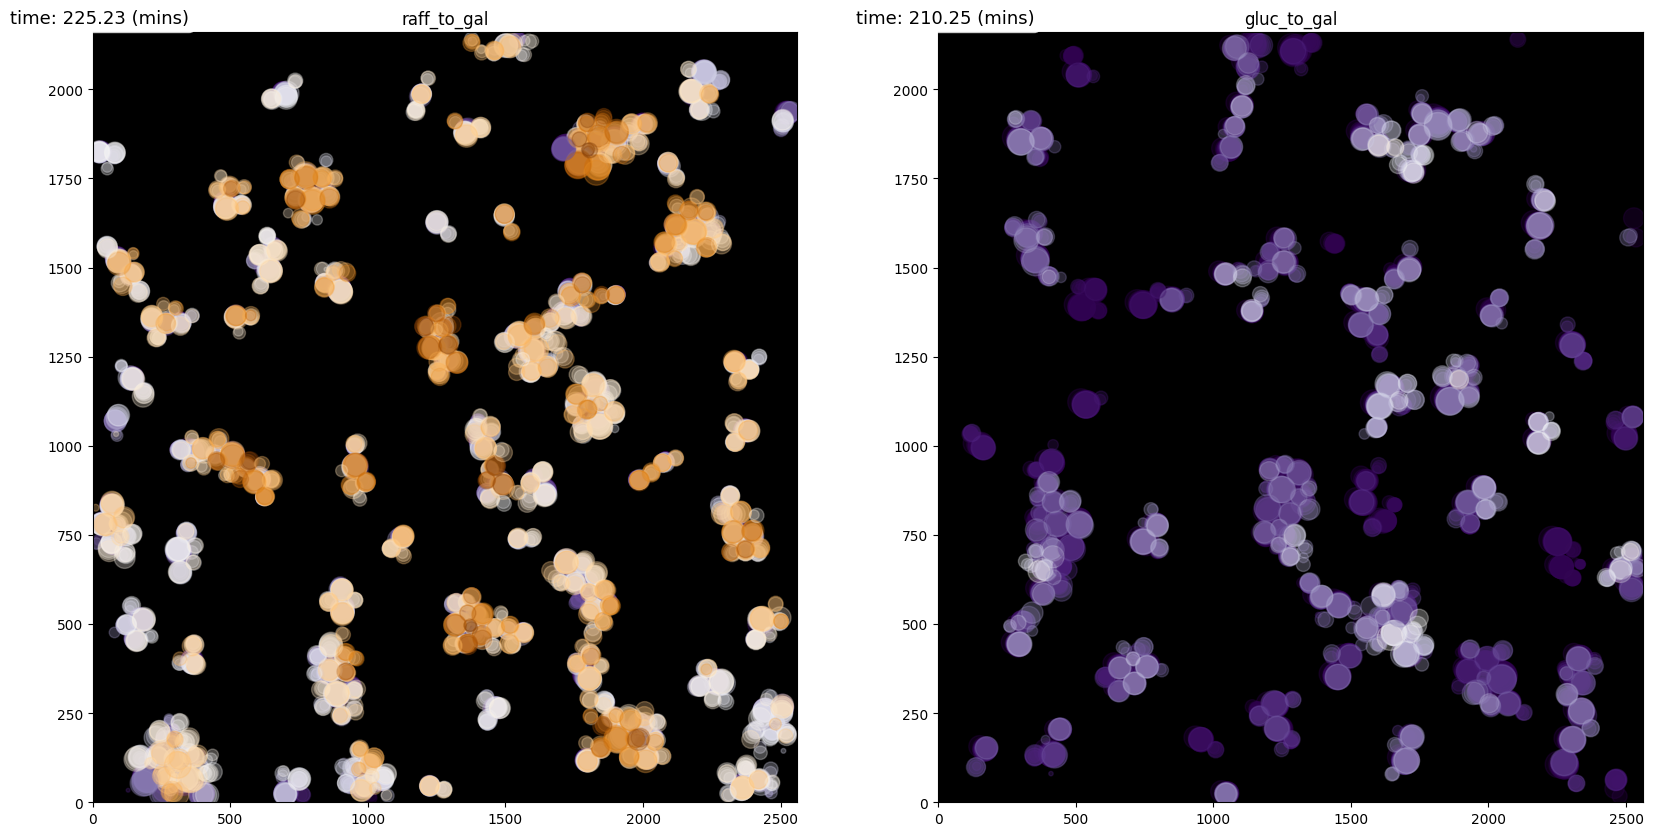

In [18]:
titles, [df1, df2] = list(data.keys()), list(data.values())


for frame in np.linspace(0,25,78):
    clear_output(wait=True)
    
    fig, axes = plt.subplots(figsize=(20,10), ncols=2)
    
    show(df1[(df1['frame']<frame)], ax=axes[0], color='rfp_mean')
    
    show(df2[(df2['frame']<frame)], ax=axes[1], color='rfp_mean')
    
    for ax, title in zip(axes,titles):
        ax.set_title(title)
        
    
    plt.show()

### your turn:

try the same for the gfp channel

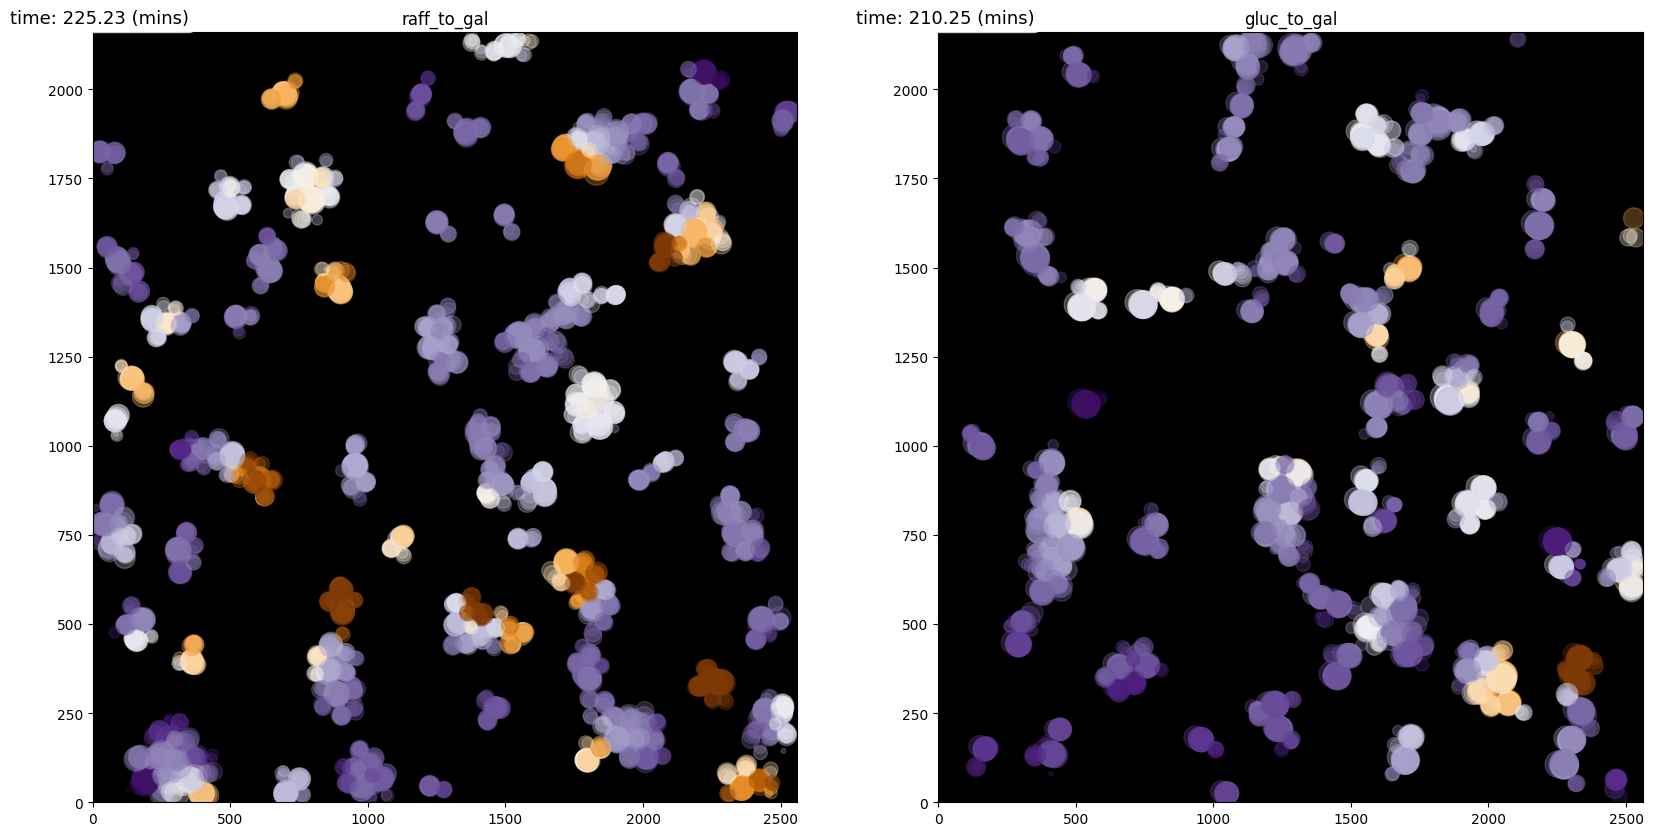

In [17]:
##########################
#   Put your code here   #
##########################
titles, [df1, df2] = list(data.keys()), list(data.values())


for frame in np.linspace(0,25,78):
    clear_output(wait=True)
    
    fig, axes = plt.subplots(figsize=(20,10), ncols=2)
    
    show(df1[(df1['frame']<frame)], ax=axes[0], color='gfp_mean')
    
    show(df2[(df2['frame']<frame)], ax=axes[1], color='gfp_mean')
    
    for ax, title in zip(axes,titles):
        ax.set_title(title)
        
    
    plt.show()

## Cutting the Live Images to the Same Length

As you can see one of the live images is much longer than the other one. Cut the length of the longer live imaging video to make them the same length.

In [ ]:
filter_time=data['gluc_to_gal']['time_min']<= data['raff_to_gal']['time_min'].max() #put time to cut here
data['gluc_to_gal']=data['gluc_to_gal'][filter_time]


ValueError: If using all scalar values, you must pass an index

## Familarize yourself with the data format

In [70]:
data['gluc_to_gal'].head()

,frame,rfp_mean,rfp_median,rfp_std,gfp_mean,gfp_median,gfp_std,area,bbox_0,bbox_1,bbox_2,bbox_3,y,x,time_min,label
0,0,13.679906,12.363808,23.899538,766.351502,762.649292,185.846634,1934,9,2438,75,2479,37.915719,2458.051189,0.197829,1
1,0,23.772545,24.529938,27.937557,762.994019,780.485718,130.473663,562,406,1886,435,1912,420.875445,1898.722420,0.197829,2
2,0,22.713850,23.382233,25.426453,780.727417,831.815918,190.030823,609,603,1309,630,1337,615.921182,1322.701149,0.197829,3
3,0,76.695663,78.022339,28.169275,644.331238,674.691406,140.970230,394,663,2302,686,2325,674.220812,2313.086294,0.197829,4
4,0,26.815466,23.617249,25.094053,1229.727173,1243.306885,204.629593,793,660,412,692,444,675.633039,427.037831,0.197829,7


- What is the meaning of the different columns?

In [ ]:
# Describe your asnwer here

- What does every row represent?

In [ ]:
# Describe your asnwer here

## You are on your own now!

Much like at the end of the first Lord of the Rings film, our fellowship has fallen apart, and it has now become your sole responsibility to cast the One Ring into the fiery depths of Mount Doom. Metaphorically speaking, of course. Although your task might prove to be slightly more daunting than the destruction of Sauron's Middle-earthly being, namely, producing several plots of the provided data.

Some suggestions for the plots you can create are: 

1) The total segmented area of all cells over time.
2) The total fluorescence of all cells (RFP and GFP channels) over time.

But of course, these figures we could have produced with a mere plate reader, so we should also try to:

3) Plot the growth of single-cell traces over time.
4) Plot the increase of single cells' fluorescence (RFP and GFP channels) over time. 

Any sidequests you might encounter along the way are, of course, encouraged.

ps: you can convert pixels to nm. 1 pixel  = 65 nm.

## Trace cells over time

/var/folders/59/vcwymf257_540j1np2_6zvgh0000gn/T/ipykernel_54091/1209742188.py:16: UserWarning: The palette list has more values (130) than needed (10), which may not be intended.
  sns.lineplot(stable_cells_raf,x="time_min",y="area_nm",hue="label",palette=palette,legend=False,ax=axes[0,1])
/var/folders/59/vcwymf257_540j1np2_6zvgh0000gn/T/ipykernel_54091/1209742188.py:23: UserWarning: The palette list has more values (130) than needed (10), which may not be intended.
  sns.lineplot(stable_cells_raf,x="time_min",y="rfp_median",hue="label",palette=palette,legend=False,ax=axes[1,1])
/var/folders/59/vcwymf257_540j1np2_6zvgh0000gn/T/ipykernel_54091/1209742188.py:29: UserWarning: The palette list has more values (130) than needed (10), which may not be intended.
  sns.lineplot(stable_cells_raf,x="time_min",y="gfp_median",hue="label",palette=palette,legend=False,ax=axes[2,1])


Text(0.5, 0, 'Time (min)')

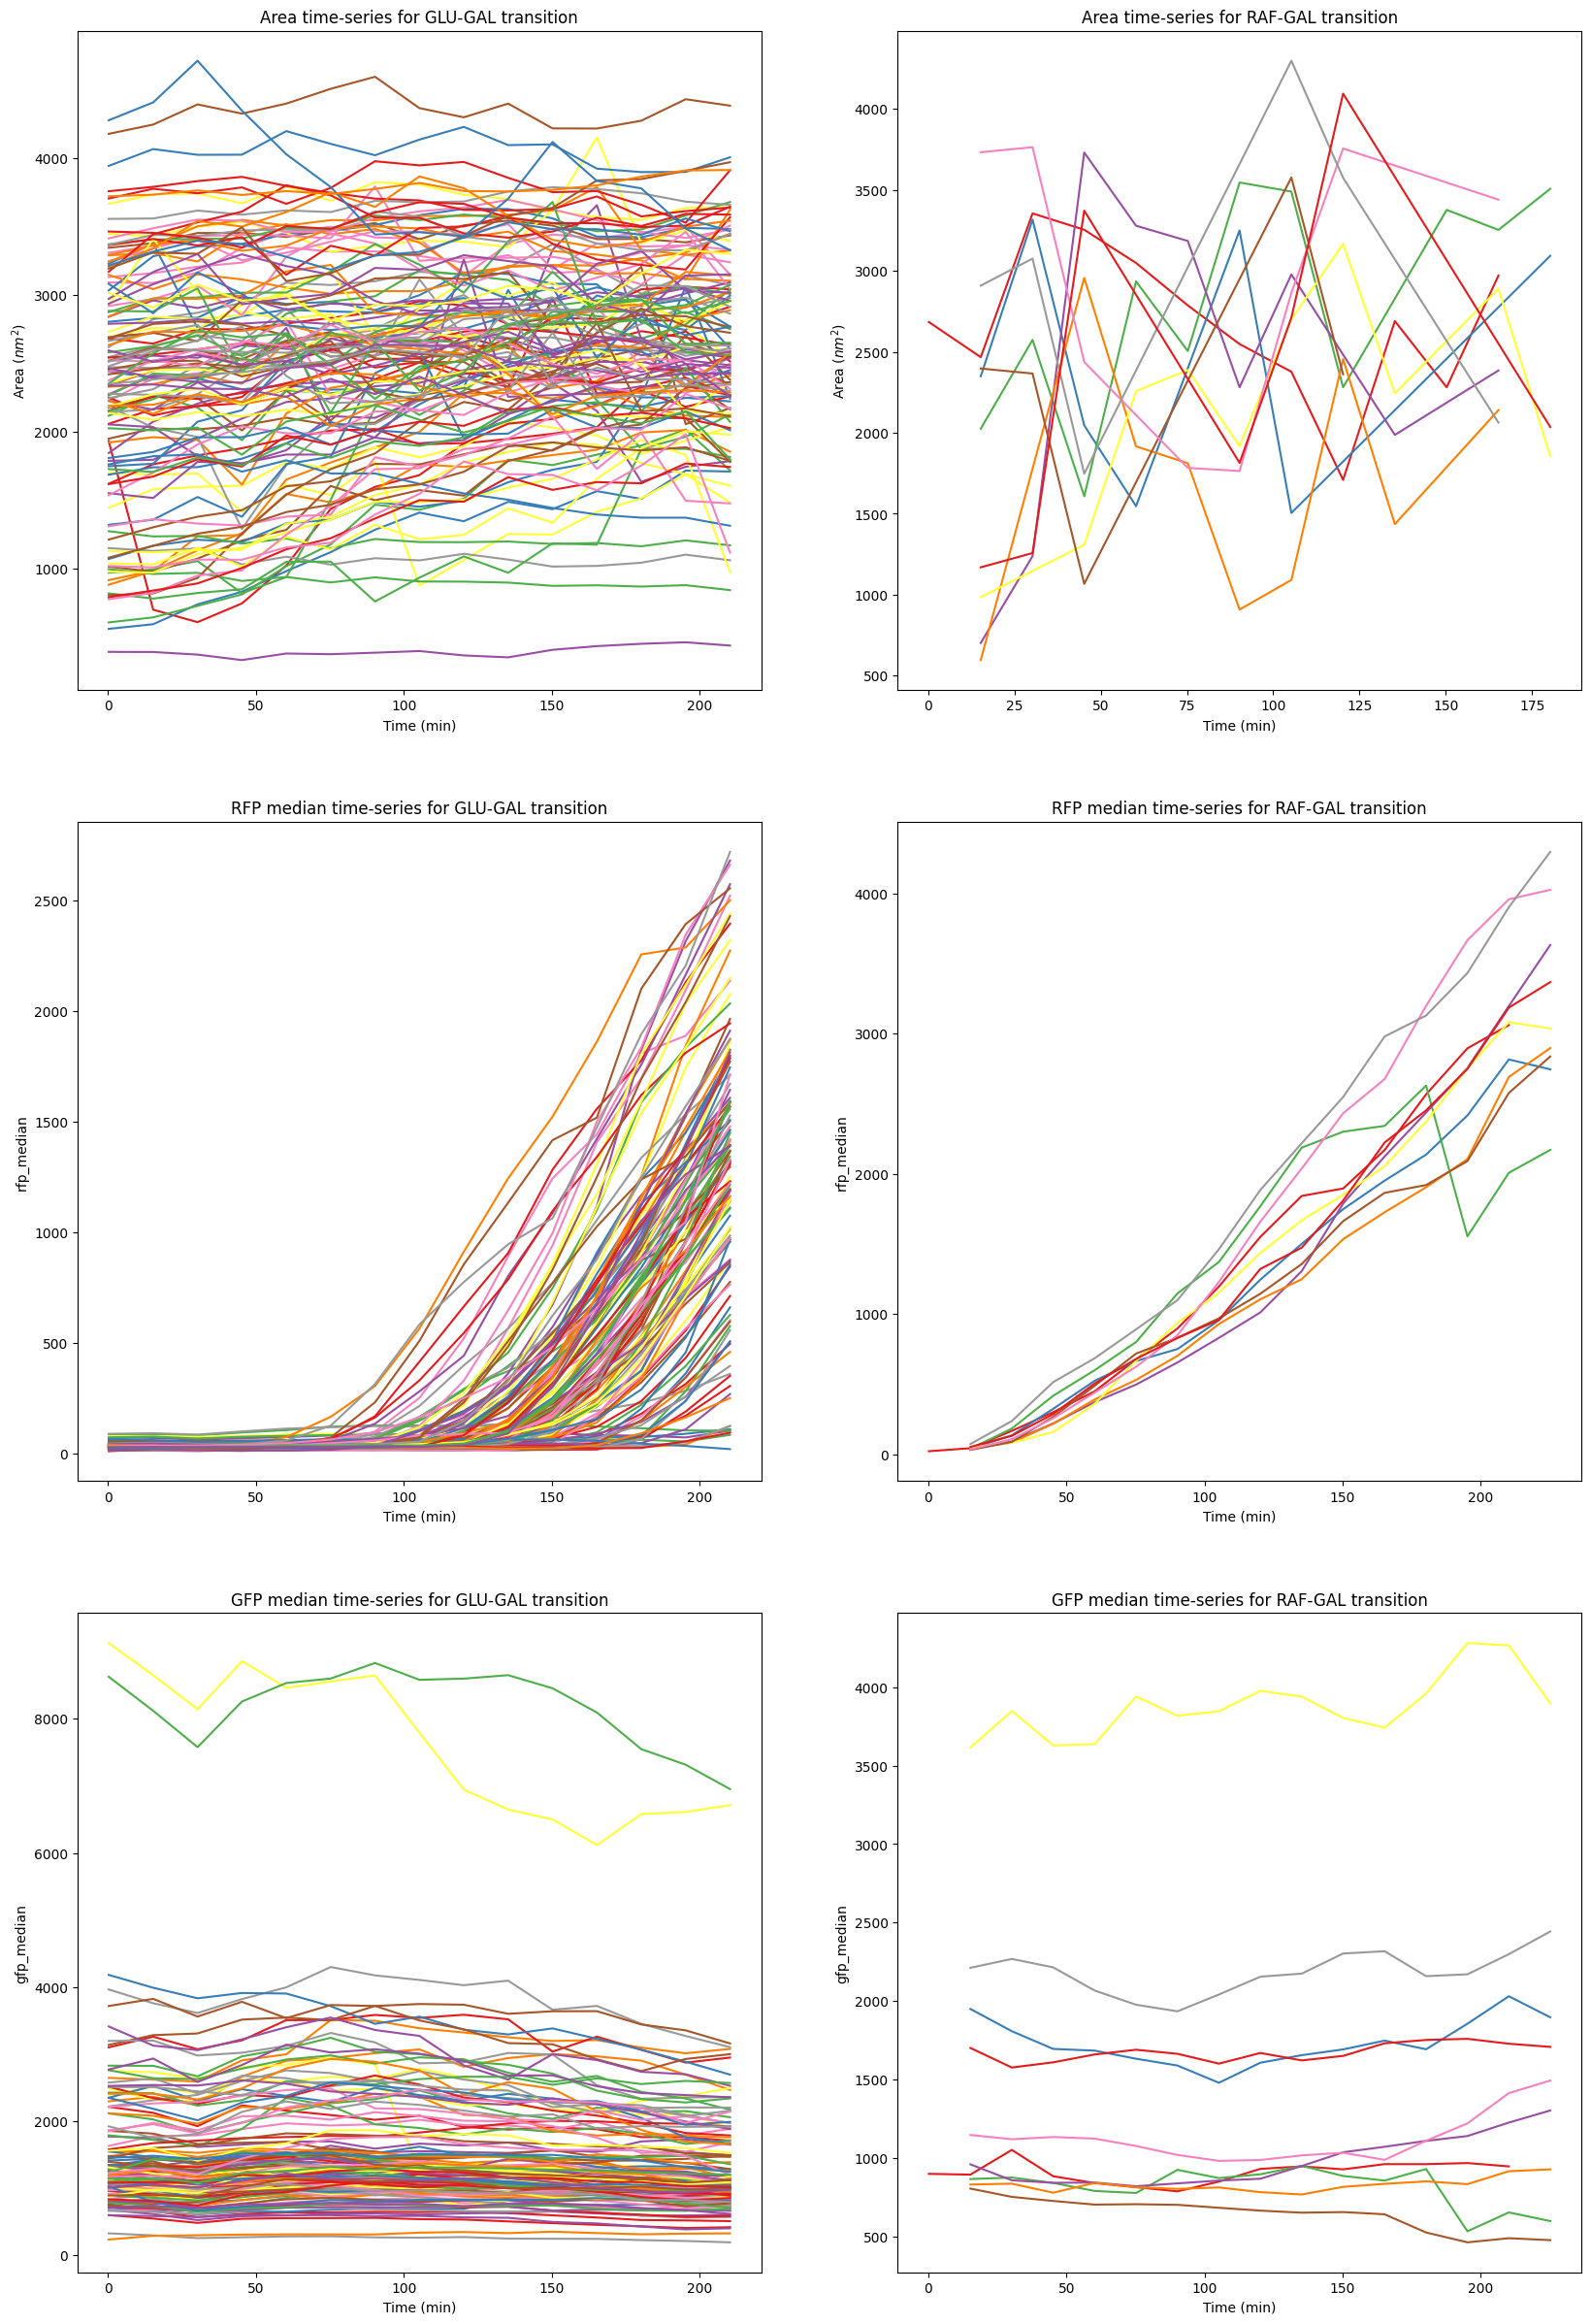

In [81]:
stable_cells_glu = data['gluc_to_gal'].groupby('label').filter(lambda x: x['frame'].nunique() == 15)
stable_cells_raf = data['raff_to_gal'].groupby('label').filter(lambda x: x['frame'].nunique() == 15)
stable_cells_raf['label']=stable_cells_raf['label'].astype(str)
stable_cells_glu['label']=stable_cells_glu['label'].astype(str)

stable_cells_glu["area_nm"]=stable_cells_glu["area"]
stable_cells_raf["area_nm"]=stable_cells_glu["area"]

palette = sns.color_palette("Set1", n_colors=stable_cells_glu['label'].nunique())

fig, axes= plt.subplots(ncols=2,nrows=3,figsize=(20,30))
sns.lineplot(stable_cells_glu,x="time_min",y="area_nm",hue="label",palette=palette,legend=False,ax=axes[0,0])
axes[0,0].set_title("Area time-series for GLU-GAL transition")
axes[0,0].set_ylabel("Area ($nm^2$)")
axes[0,0].set_xlabel("Time (min)")
sns.lineplot(stable_cells_raf,x="time_min",y="area_nm",hue="label",palette=palette,legend=False,ax=axes[0,1])
axes[0,1].set_title("Area time-series for RAF-GAL transition")
axes[0,1].set_ylabel("Area ($nm^2$)")
axes[0,1].set_xlabel("Time (min)")
sns.lineplot(stable_cells_glu,x="time_min",y="rfp_median",hue="label",palette=palette,legend=False,ax=axes[1,0])
axes[1,0].set_title("RFP median time-series for GLU-GAL transition")
axes[1,0].set_xlabel("Time (min)")
sns.lineplot(stable_cells_raf,x="time_min",y="rfp_median",hue="label",palette=palette,legend=False,ax=axes[1,1])
axes[1,1].set_title("RFP median time-series for RAF-GAL transition")
axes[1,1].set_xlabel("Time (min)")
sns.lineplot(stable_cells_glu,x="time_min",y="gfp_median",hue="label",palette=palette,legend=False,ax=axes[2,0])
axes[2,0].set_title("GFP median time-series for GLU-GAL transition")
axes[2,0].set_xlabel("Time (min)")
sns.lineplot(stable_cells_raf,x="time_min",y="gfp_median",hue="label",palette=palette,legend=False,ax=axes[2,1])
axes[2,1].set_title("GFP median time-series for RAF-GAL transition")
axes[2,1].set_xlabel("Time (min)")


## 3D plots?